# Deep Q-Network (DQN) on CartPole-v1

**Deep Q-Network (DQN)** extends tabular Q-Learning to environments with continuous or very large state spaces by replacing the Q-table with a neural network function approximator $Q(s, a; \theta)$. Instead of looking up a value in a table, the network takes a state as input and outputs one Q-value per action.

The learning rule is still the Bellman optimality equation, now applied as a regression target for the network:

$$Q(s, a; \theta) \leftarrow Q(s, a; \theta) + \alpha \left[ r + \gamma \max_{a'} Q(s', a'; \theta) - Q(s, a; \theta) \right]$$

which in practice is implemented as gradient descent on the **TD error** as a squared loss:

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(r + \gamma \max_{a'} Q(s', a'; \theta) - Q(s, a; \theta)\right)^2\right]$$

Two ideas make this stable enough to train with a neural network (naively combining Q-Learning with function approximation tends to diverge):

1. **Experience replay** — transitions $(s, a, r, s', \text{done})$ are stored in a buffer and sampled in random minibatches for each update, instead of training on consecutive, highly correlated transitions as they occur.
2. **A target network** — a slowly-updated copy of the Q-network used to compute the TD target, so the network isn't chasing a target that shifts on every single gradient step.

This implementation uses experience replay but keeps things intentionally simple by computing the TD target from the *same* network being trained (`policy_net`), rather than a separate target network. See **Results** at the end for what that trade-off costs.

In [18]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import cv2

In [19]:
# Hyperparams
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 1000
LEARNING_RATE = 0.0003
BATCH_SIZE = 64
MEMORY_SIZE = 100000
NUM_EPISODES = 300

In [20]:
# Check if MPS is available
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


## Implementation

### Q-network

Replaces the Q-table with a small feedforward network: a hidden layer of 512 ReLU units maps the 4-dimensional CartPole state to a learned representation, and a linear output layer produces one raw Q-value per action. The output layer must stay linear (no activation) — Q-values are unbounded and can be negative, e.g. this environment's `-1` penalty on failure.

In [21]:
class DQN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_shape, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Experience replay buffer

A fixed-size FIFO buffer (`deque`) of past transitions. Sampling a random minibatch from it for every update — rather than training on transitions in the order they occur — breaks the strong correlation between consecutive frames of a single trajectory and lets each transition be reused across multiple updates instead of being discarded after one step. Both effects stabilize training compared to a purely online update.

In [22]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return (np.array(state), np.array(action), np.array(reward), np.array(next_state), np.array(done))

    def __len__(self):
        return len(self.buffer)

### Epsilon-greedy action selection

Same exploration strategy as tabular Q-Learning/Dyna-Q: with probability `epsilon` pick a uniformly random action, otherwise pick the action with the highest predicted Q-value under the current network. `epsilon` decays linearly over training so the agent explores heavily early on and exploits its learned policy later.

In [23]:
def select_action(state, epsilon, n_actions, policy_net):
    if random.random() > epsilon:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0).to(device)
            return policy_net(state).argmax(1).item()
    else:
        return random.randrange(n_actions)

### Optimization step

Samples a minibatch of `BATCH_SIZE` transitions from the replay buffer and takes one gradient step to reduce the TD error:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_i \left(Q(s_i, a_i;\theta) - \underbrace{\left(r_i + \gamma \max_{a'} Q(s'_i, a';\theta) \cdot (1 - \text{done}_i)\right)}_{\text{target, detached from the graph}}\right)^2$$

The `(1 - done)` term zeroes out the bootstrapped future value for terminal transitions, since there is no next state to estimate a value for. `expected_q_value.detach()` stops gradients from flowing into the target half of the loss — only `q_value` (the network's *current* prediction) should be updated by this loss, not the target itself.

In [24]:
def optimize_model(memory: ReplayBuffer, policy_net: DQN, optimizer: optim):
    if len(memory) < BATCH_SIZE:
        return

    state, action, reward, next_state, done = memory.sample(BATCH_SIZE)

    state = torch.FloatTensor(state).to(device)
    action = torch.LongTensor(action).to(device)
    reward = torch.FloatTensor(reward).to(device)
    next_state = torch.FloatTensor(next_state).to(device)
    done = torch.FloatTensor(done).to(device)

    q_values = policy_net(state)
    next_q_values = policy_net(next_state)
    next_q_state_values = policy_net(next_state)

    q_value = q_values.gather(1, action.unsqueeze(1)).squeeze(1)
    next_q_value = next_q_state_values.gather(1, next_q_values.argmax(1).unsqueeze(1)).squeeze(1)
    expected_q_value = reward + GAMMA * next_q_value * (1 - done)

    loss = (q_value - expected_q_value.detach()).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

## Environment — CartPole-v1

[CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) balances a pole on a cart that can move left or right. The state is a 4-dimensional continuous vector (cart position, cart velocity, pole angle, pole angular velocity) — too large to tabulate, which is exactly the setting DQN is designed for.

| | |
|---|---|
| **State space** | 4 continuous values |
| **Action space** | 2 discrete actions — push cart left (0) or right (1) |
| **Reward** | +1 for every timestep the pole stays upright |
| **Episode ends** | pole falls past ~15°, cart leaves the track, or 500 steps are reached |

An explicit `-1` penalty is added on top of the environment's own reward when the episode ends in failure (`reward <= 0` and `done`), giving the network a clearer negative signal to distinguish "pole fell" from "still balancing."

## Training

| Hyperparameter | Value | Role |
|---|---|---|
| `GAMMA` | 0.99 | Discount factor — future reward matters almost as much as immediate reward |
| `EPSILON_START` → `EPSILON_END` | 1.0 → 0.1 | Linear decay over `EPSILON_DECAY` steps, from full exploration to mostly greedy |
| `LEARNING_RATE` | 3e-4 | Adam optimizer step size |
| `BATCH_SIZE` | 64 | Minibatch size sampled from replay for each update |
| `MEMORY_SIZE` | 100,000 | Replay buffer capacity |
| `NUM_EPISODES` | 300 | Total training episodes |

`optimize_model` only starts updating once the buffer holds at least one full batch (`len(memory) >= BATCH_SIZE`), so the very first steps of training are pure data collection.

In [25]:
env = gym.make('CartPole-v1')
input_shape = 4
num_actions = env.action_space.n

policy_net = DQN(input_shape, num_actions).to(device)
optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
memory = ReplayBuffer(MEMORY_SIZE)

epsilon = EPSILON_START
epsilon_decay = (EPSILON_START - EPSILON_END) / EPSILON_DECAY
steps_done = 0

episode_rewards = []

for episode in range(NUM_EPISODES):
    state, _ = env.reset()
    total_reward = 0

    for t in range(10000):
        action = select_action(state, epsilon, num_actions, policy_net)
        next_state, reward, done, _, _ = env.step(action)
        if (done and reward <= 0):
            reward = -1
        total_reward += reward

        memory.push(state, action, reward, next_state, done)

        state = next_state

        optimize_model(memory, policy_net, optimizer)

        if done:
            break

        epsilon = max(EPSILON_END, epsilon - epsilon_decay)
        steps_done += 1

    episode_rewards.append(total_reward)
    print(f"Episode {episode+1}, Total reward: {total_reward}")

env.close()

Episode 1, Total reward: 15.0
Episode 2, Total reward: 13.0
Episode 3, Total reward: 17.0
Episode 4, Total reward: 18.0
Episode 5, Total reward: 18.0
Episode 6, Total reward: 26.0
Episode 7, Total reward: 10.0
Episode 8, Total reward: 17.0
Episode 9, Total reward: 16.0
Episode 10, Total reward: 16.0
Episode 11, Total reward: 11.0
Episode 12, Total reward: 20.0
Episode 13, Total reward: 26.0
Episode 14, Total reward: 22.0
Episode 15, Total reward: 13.0
Episode 16, Total reward: 17.0
Episode 17, Total reward: 28.0
Episode 18, Total reward: 14.0
Episode 19, Total reward: 11.0
Episode 20, Total reward: 18.0
Episode 21, Total reward: 10.0
Episode 22, Total reward: 11.0
Episode 23, Total reward: 17.0
Episode 24, Total reward: 17.0
Episode 25, Total reward: 8.0
Episode 26, Total reward: 11.0
Episode 27, Total reward: 14.0
Episode 28, Total reward: 10.0
Episode 29, Total reward: 12.0
Episode 30, Total reward: 13.0
Episode 31, Total reward: 14.0
Episode 32, Total reward: 12.0
Episode 33, Total 

### Reward curve

Raw per-episode reward is extremely noisy — a single unlucky or lucky trajectory can swing it by hundreds of points once the agent starts balancing for a long time. A 30-episode moving average smooths that out and makes the underlying learning trend visible.

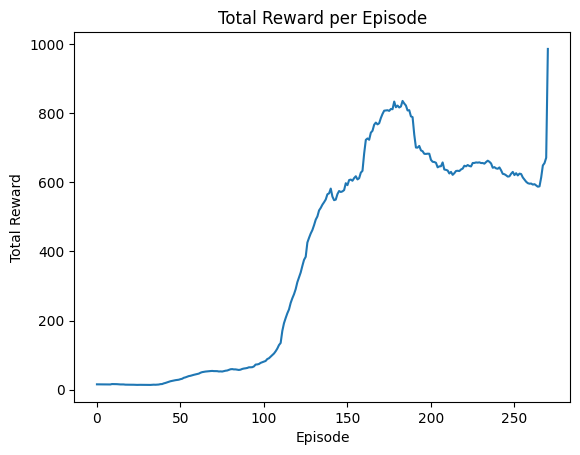

In [26]:
def moving_average(data, window_size):
    """
    Calculate the moving average of a given list of numbers

    Parameters:
    - data: List of numbers.
    - window_size: Size of the moving window.

    Returns:
    List of moving averages.
    """

    if len(data) < window_size:
        return []

    moving_averages = []
    for i in range(len(data) - window_size + 1):
        window = data[i:i + window_size]
        window_average = sum(window) / window_size
        moving_averages.append(window_average)

    return moving_averages

ma = moving_average(episode_rewards, 30)

# Plot cumulative rewards
plt.plot(ma)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward per Episode')
plt.show()

## Results — strengths and weaknesses

**Strengths of DQN over tabular methods (Q-Learning, Dyna-Q):**
- **Generalization across states.** A neural network can represent Q-values for continuous or astronomically large state spaces (like CartPole's 4D continuous state) where a table is impossible to build or would never fill in. It also generalizes: visiting one state updates the network's estimate for *similar* states too, instead of touching a single isolated table entry.
- **Experience replay improves sample efficiency and stability.** Reusing past transitions and decorrelating consecutive updates makes learning far more stable than a naive online TD update with a function approximator.
- **Off-policy.** Like Q-Learning, DQN learns the optimal policy from any behavior policy's data (here, epsilon-greedy), so old experience in the replay buffer stays valid to learn from even as the policy improves.

**Weaknesses:**
- **Catastrophic forgetting.** Because a single shared network approximates Q-values for *all* states, a gradient update driven by recently-sampled transitions can overwrite what the network had learned about states it hasn't visited in a while — unlike a Q-table, where updating `Q[s, a]` never touches any other entry. This shows up as sudden drops in performance mid-training even after the agent looked like it had learned a good policy — visible above as the dips in the moving-average curve even during the generally-improving second half of training. Experience replay mitigates this by continually re-exposing the network to a mix of old and new transitions, but doesn't eliminate it.
- **Moving target / instability.** This implementation computes the TD target with the *same* network being optimized (`policy_net`), so every gradient step immediately shifts the target used on the next step — the network is chasing a target it is simultaneously moving. The standard fix is a separate **target network**, synced every N steps (or via Polyak averaging), which is omitted here for simplicity; adding one would noticeably smooth out training.
- **Overestimation bias.** Taking `max` over the network's own noisy Q-value estimates when constructing the target systematically biases values upward, since estimation errors are more likely to inflate the max than to be averaged out. **Double DQN** — selecting the action with the online network but evaluating it with the target network — addresses this directly.
- **Sample inefficiency.** DQN needs many more environment interactions than model-based tabular methods like Dyna-Q, which extract extra learning from a handful of real steps by "replaying" them through a learned model. DQN only ever learns from transitions it has actually collected, even if it revisits them multiple times.
- **Hyperparameter sensitivity.** Learning rate, replay buffer size, batch size, and the epsilon decay schedule all interact, and CartPole with these exact settings can still swing between solved and unstable across runs — a known symptom of combining function approximation, bootstrapping, and off-policy learning (the "deadly triad").